# **Loan Default Prediction**

### **Introduction**: This project aims to analyze business problems, preprocess data, build machine learning models, and evaluate them for performance and fairness to predict loan default and recommend actions based on your findings.

## **1. Data Analysis and Cleaning**

### **Load and inspect the dataset**

In [ ]:
# Import libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import ConfusionMatrixDisplay

In [ ]:
# Load the dataset

loan_data = pd.read_csv("bank-loan.csv")

loan_data.head()

,age,ed,employ,address,income,debtinc,creddebt,othdebt,default
0,41,3,17,12,176,9.3,11.359392,5.008608,1.0
1,27,1,10,6,31,17.3,1.362202,4.000798,0.0
2,40,1,15,14,55,5.5,0.856075,2.168925,0.0
3,41,1,15,14,120,2.9,2.658720,0.821280,0.0
4,24,2,2,0,28,17.3,1.787436,3.056564,1.0


In [ ]:
# Check the dataset structure and content

loan_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       850 non-null    int64  
 1   ed        850 non-null    int64  
 2   employ    850 non-null    int64  
 3   address   850 non-null    int64  
 4   income    850 non-null    int64  
 5   debtinc   850 non-null    float64
 6   creddebt  850 non-null    float64
 7   othdebt   850 non-null    float64
 8   default   700 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 59.9 KB


In [7]:
# Identify the missing values

loan_data.isnull().sum()

age           0
ed            0
employ        0
address       0
income        0
debtinc       0
creddebt      0
othdebt       0
default     150
dtype: int64

In [24]:
# Handle missing values
# Since the missing values are in the target variable, we opt to drop them

loan_data = loan_data.dropna(subset=['default'])

In [11]:
loan_data.isnull().sum()

age         0
ed          0
employ      0
address     0
income      0
debtinc     0
creddebt    0
othdebt     0
default     0
dtype: int64

In [8]:
# Summary statistics

loan_data.describe()

,age,ed,employ,address,income,debtinc,creddebt,othdebt,default
count,850.000000,850.000000,850.000000,850.000000,850.000000,850.000000,850.000000,850.000000,700.000000
mean,35.029412,1.710588,8.565882,8.371765,46.675294,10.171647,1.576805,3.078789,0.261429
std,8.041432,0.927784,6.777884,6.895016,38.543054,6.719441,2.125840,3.398803,0.439727
min,20.000000,1.000000,0.000000,0.000000,13.000000,0.100000,0.011696,0.045584,0.000000
25%,29.000000,1.000000,3.000000,3.000000,24.000000,5.100000,0.382176,1.045942,0.000000
50%,34.000000,1.000000,7.000000,7.000000,35.000000,8.700000,0.885091,2.003243,0.000000
75%,41.000000,2.000000,13.000000,12.000000,55.750000,13.800000,1.898440,3.903001,1.000000
max,56.000000,5.000000,33.000000,34.000000,446.000000,41.300000,20.561310,35.197500,1.000000


In [ ]:
# Check the distribution of the target variable 

loan_data['default'].value_counts()

default
0.0    517
1.0    183
Name: count, dtype: int64

In [14]:
# Display in percentage

loan_data['default'].value_counts(normalize=True) * 100

default
0.0    73.857143
1.0    26.142857
Name: proportion, dtype: float64

The above distribution shows imbalance in the outcome variable classes.

### **Visualize distributions and relationships between features**

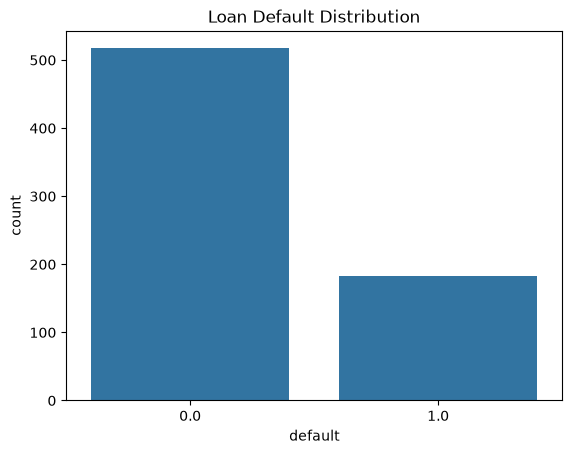

In [17]:
# Display the Default distribution

sns.countplot(data=loan_data, x="default")
plt.title("Loan Default Distribution")
plt.show()

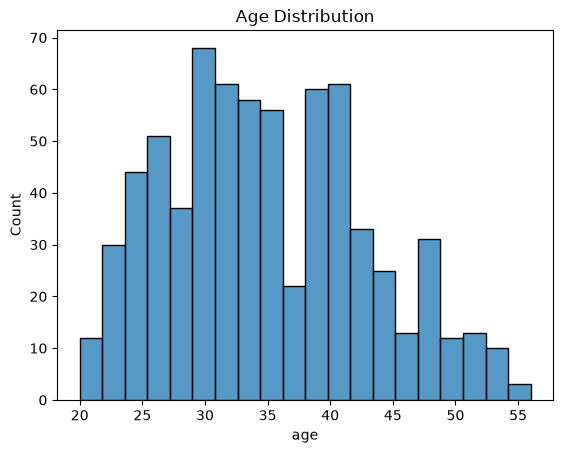

In [18]:
# Age distribution

sns.histplot(data=loan_data, x='age', bins=20)
plt.title('Age Distribution')
plt.show()

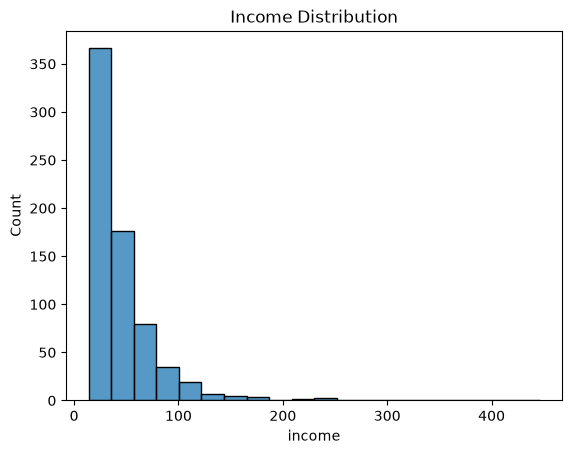

In [19]:
# Income distribution

sns.histplot(data=loan_data, x='income', bins=20)
plt.title('Income Distribution')
plt.show()

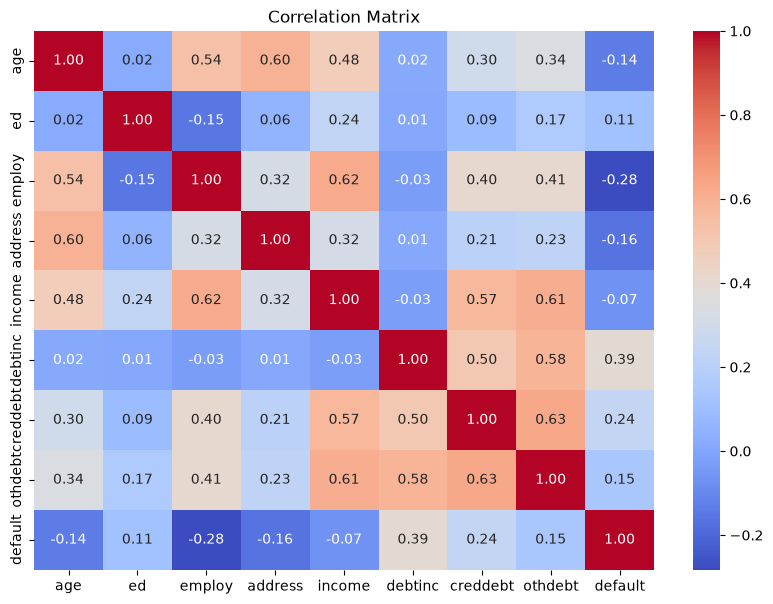

In [ ]:
# Correlation matrix

plt.figure(figsize=(10, 7))

sns.heatmap(
    loan_data.corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm')

plt.title('Correlation Matrix')
plt.show()

## **2. Feature Engineering**

### **Create new features**

In [26]:
# Compute the total debt

loan_data['total_debt'] = (
    loan_data['creddebt'] + loan_data['othdebt'])

In [28]:
# Compute the Employment-to-age ratio

loan_data['employ_age_ratio'] = (
    loan_data['employ'] / loan_data['age'])

In [29]:
loan_data.head()

,age,ed,employ,address,income,debtinc,creddebt,othdebt,default,total_debt,employ_age_ratio
0,41,3,17,12,176,9.3,11.359392,5.008608,1.0,16.368,0.414634
1,27,1,10,6,31,17.3,1.362202,4.000798,0.0,5.363,0.370370
2,40,1,15,14,55,5.5,0.856075,2.168925,0.0,3.025,0.375000
3,41,1,15,14,120,2.9,2.658720,0.821280,0.0,3.480,0.365854
4,24,2,2,0,28,17.3,1.787436,3.056564,1.0,4.844,0.083333


### **Scale numerical features**

In [30]:
# Define X and y before scaling

X = loan_data.drop('default', axis=1)
y = loan_data['default']

In [ ]:
# Split training and testing data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y)

In [33]:
# Scale the numerical features

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## **3. Model Building and Evaluation**

In [ ]:
# Train the Random forest model

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42)

rf_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [39]:
# Make prediction

y_pred = rf_model.predict(X_test)

In [42]:
# Evaluate the model

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8214285714285714

Classification Report:
              precision    recall  f1-score   support

         0.0       0.86      0.90      0.88       103
         1.0       0.69      0.59      0.64        37

    accuracy                           0.82       140
   macro avg       0.77      0.75      0.76       140
weighted avg       0.82      0.82      0.82       140



In [ ]:
# Feature importance

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_})

feature_importance = feature_importance.sort_values(
    'Importance',
    ascending=False)

feature_importance

,Feature,Importance
5,debtinc,0.151410
6,creddebt,0.147869
9,employ_age_ratio,0.139824
8,total_debt,0.094845
7,othdebt,0.094140
2,employ,0.091091
4,income,0.086294
0,age,0.084994
3,address,0.080884
1,ed,0.028650


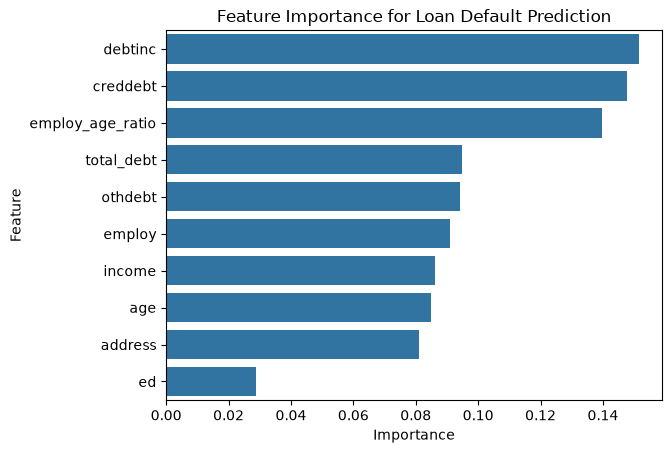

In [ ]:
sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature')

plt.title('Feature Importance for Loan Default Prediction')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

In [46]:
%pip install shap

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip
